# LAB 2: Implement a Simple Rational Agent in a Defined Environment

**Relates to:** Week 1 — Intelligent Agents, PEAS, Agent Types

## Overview

In this lab, we build a robot vacuum with two rooms: A and B. Each room is either clean or dirty. The vacuum can suck dirt, move left, or move right. We will compare a simple reflex agent and a model-based agent to understand how memory improves performance.

## Goal

Understand how an intelligent agent reacts to its environment and how memory can improve performance.

## Key Concepts

- **Reflex Agent:** Reacts only to the current situation without memory
- **Model-Based Agent:** Keeps track of what it has seen before
- **Percept:** Information the agent receives about the environment
- **Action:** What the agent chooses to do based on its percept

## Step 1: Build the Environment

We'll create a `VacuumEnvironment` class that:
- Randomly initializes two rooms (A and B) as either Clean or Dirty
- Places the vacuum in a random starting room
- Tracks performance by rewarding clean rooms and penalizing movement

The environment provides two key methods:
- `percept()`: Returns what the agent can sense (location and room status)
- `execute()`: Updates the world based on the agent's chosen action

In [ ]:
import random

class VacuumEnvironment:
    def __init__(self):
        # Randomly initialize room statuses and agent location
        self.status = {
            'A': random.choice(['Clean', 'Dirty']),
            'B': random.choice(['Clean', 'Dirty'])
        }
        # Example
        # self.status ={A:'Clean',B:'Dirty'}
        self.agent_location = random.choice(['A', 'B'])
        self.performance = 0

    def percept(self):
        """Returns what the agent can perceive: location and room status"""
        return (self.agent_location, self.status[self.agent_location])

    def execute(self, action):
        """Executes the agent's action and updates the world"""
        if action == 'Suck':
            # If room is dirty, clean it
            # self.status['A']
            if self.status[self.agent_location] == 'Dirty':
                self.status[self.agent_location] = 'Clean'
            #else:
            #    self.performance -= 1  # Penalize unnecessary cleaning
        elif action == 'Right':
            # Move to room B
            self.agent_location = 'B'
            self.performance -= 1  # Penalize movement
        elif action == 'Left':
            # Move to room A
            self.agent_location = 'A'
            self.performance -= 1  # Penalize movement

        # Reward for each clean room
        for room in self.status:
            # self.status['A']
            if self.status[room] == 'Clean':
                self.performance += 1 # Reward
                
        # change the status of rooms randomly after each action
        # self.status={
        #     'A': random.choice(['Clean', 'Dirty']),
        #     'B': random.choice(['Clean', 'Dirty'])
        # }

## Step 2: Define the Agents

### Simple Reflex Agent
A **simple reflex agent** has no memory. It responds only to the current percept:
- If the current room is dirty → Suck
- If in room A → Move Right
- If in room B → Move Left

### Model-Based Agent
A **model-based agent** maintains an internal model of the world:
- Remembers the status of each room it has visited
- If a room is dirty → Suck
- If both rooms are known to be clean → Stop (NoOp)
- Otherwise → Move to explore unseen rooms

The model-based agent's memory allows it to stop wasting energy once the environment is fully clean.

In [21]:
def simple_reflex_agent(percept):
    """Simple reflex agent - reacts only to current percept, no memory"""
    location, status = percept
    #percept = {location,status}
    if status == 'Dirty':
        return 'Suck'  # Clean if dirty
    
    if location == 'A':
        return 'Right'  # Move right if in A
    
    return 'Left'  # Move left if in B


class ModelBasedAgent:
    """Model-based agent - maintains internal model of world"""
    
    def __init__(self):
        # Internal model: track known status of each room
        self.model = {'A': None, 'B': None}

    def act(self, percept):
        """Decide action based on percept and internal model"""
        location, status = percept
        
        # Update model with current observation
        self.model[location] = status

        if status == 'Dirty':
            return 'Suck'  # Clean if dirty

        # If both rooms are known to be clean, do nothing
        if self.model['A'] == 'Clean' and self.model['B'] == 'Clean':
            return 'NoOp'

        # Move to other room to explore or verify
        return 'Right' if location == 'A' else 'Left'

## Step 3: Run the Simulation

We'll create a test harness that:
1. Initializes a new environment
2. Runs the agent for a fixed number of steps (6)
3. Returns the final performance score

By resetting the random seed before each trial, we ensure both agents operate in the same environment for a fair comparison.

In [ ]:
def run_trial(agent_type, steps=6):
    """Run a single trial of the specified agent type"""
    env = VacuumEnvironment()
    model_agent = ModelBasedAgent() if agent_type == 'model' else None

    # Run for specified number of steps
    for step in range(steps):
        percept = env.percept()
        
        if agent_type == 'reflex':
            action = simple_reflex_agent(percept)
        else:
            action = model_agent.act(percept)
        
        env.execute(action)

    return env.performance


# Run fair comparison with same random seed for both agents
random.seed(42)
reflex_score = run_trial('reflex')

random.seed(42)
model_score = run_trial('model')

print('=' * 50)
print('Agent Performance Comparison')
print('=' * 50)
print(f'Simple Reflex Agent performance: {reflex_score}')
print(f'Model-Based Agent performance:  {model_score}')
print('=' * 50)

# Calculate the difference
difference = model_score - reflex_score
if difference > 0:
    print(f'\n✓ Model-based agent outperformed by {difference} points!')
elif difference < 0:
    print(f'\n✓ Reflex agent outperformed by {abs(difference)} points!')
else:
    print('\n✓ Both agents performed equally!')

Agent Performance Comparison
Simple Reflex Agent performance: 5
Model-Based Agent performance:  7

✓ Model-based agent outperformed by 2 points!


findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

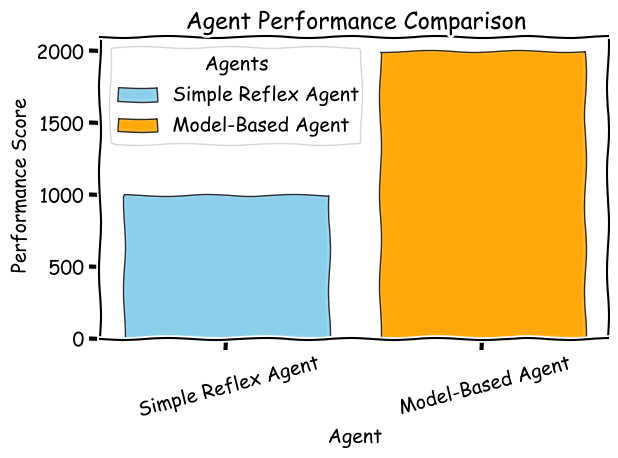

In [23]:
with plt.xkcd():
    plt.bar(labels[0], scores[0], color='skyblue', edgecolor='black',
            alpha=0.8, label=labels[0])
    plt.bar(labels[1], scores[1], color='orange', edgecolor='black',
            alpha=0.8, label=labels[1])

    plt.xlabel('Agent')
    plt.ylabel('Performance Score')
    plt.title('Agent Performance Comparison')
    plt.xticks(rotation=15)
    plt.legend(title='Agents')
    plt.tight_layout()
    plt.show()


## Analysis & Conclusions

### Key Observations

1. **Reflex vs. Model-Based Performance**
   - The simple reflex agent wastes energy by unnecessarily moving between rooms
   - The model-based agent learns when to stop, conserving energy
   - In controlled environments, the model-based approach is generally superior

2. **Why Model-Based Wins**
   - **Memory:** The model-based agent remembers visited rooms
   - **Efficiency:** It can recognize when both rooms are clean and stop moving
   - **Fewer Penalties:** Less unnecessary movement = higher performance score

3. **Trade-offs**
   - Model-based agents require more computational resources
   - In very dynamic environments (rooms getting dirty again), the reflex agent might adapt faster
   - The superiority of each approach depends on the environment's characteristics

### Exploration Questions

Try experimenting with:
- **More steps:** What happens with 10, 20, or 50 steps?
- **More rooms:** Extend the system to 3 or 4 rooms
- **Dynamic environments:** Make rooms randomly become dirty again
- **Different performance metrics:** Reward/penalize different actions differently